# Validation — enriched vs random TF force

In [1]:
# Dataset locations for this notebook come from ../datasets.yaml.
# Edit that file to point at your own copies -- do not hardcode paths below.
from focal.io import DatasetPaths

# DatasetPaths.find() walks up from the kernel's working directory to the first
# datasets.yaml (or uses $FOCAL_DATASETS), so it works wherever Jupyter was started.
config = DatasetPaths.find()


In [2]:
import numpy as np
import pandas as pd
import os
import joblib
import pickle
import math
import ast

from scipy.stats import median_abs_deviation, hypergeom, mannwhitneyu
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

%matplotlib inline

figure_params = {
    'dpi': 300, 
    'bbox_inches': 'tight', 
    'format': 'svg', 
    'transparent': True
}

plt.rcParams.update({
    "text.usetex": False,
    "svg.fonttype": 'none'
})

# Saving plots with editable text
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts (editable text)

# All figures from this notebook are written as PDFs here (folder is gitignored).
RESULTS_DIR = os.path.join(os.getcwd(), 'Fig4_2_results')
os.makedirs(RESULTS_DIR, exist_ok=True)

def save_pdf(fig, name):
    fig.savefig(os.path.join(RESULTS_DIR, f"{name}.pdf"),
                format='pdf', bbox_inches='tight', transparent=True)

# Link-set palette, shared with state_specific/perturbation/PS_Bcell_dynamic.ipynb:
# state-specific = blue, episodic/dynamic = orange, random/other = light grey.
LINK_COLORS = {
    'State-specific': 'dodgerblue',
    'Episodic': 'tab:orange',
    'random': '#bbbbbb',
}
GROUP_ORDER = ['State-specific', 'Episodic', 'random']
GROUP_COLORS = [LINK_COLORS[g] for g in GROUP_ORDER]
# BindingPhases.plot_box takes colormaps, not colours; single-colour maps give the same palette.
LINK_CMAPS = {k: mcolors.ListedColormap([v], name=f'link_{k}') for k, v in LINK_COLORS.items()}

def drop_zero_force(df, groups=('State-specific', 'Episodic')):
    """Drop enriched links with abs-max TF force == 0 (not computable / absent from the
    force network). The random null is left untouched so it stays the same size-matched,
    seeded draw regardless of this filter."""
    zero = df['group'].isin(groups) & (df['abs_max_force'] == 0)
    if zero.any():
        print('Dropped zero-force links:',
              df.loc[zero].groupby('group')['link'].apply(list).to_dict())
    return df.loc[~zero].reset_index(drop=True)


In [3]:
import dictys

from focal.temporal import *      # classes AND their figures
from focal.utils import *         # gene / state helpers (was utils_custom)

In [4]:
import importlib
import focal.utils
import focal.temporal._source, focal.temporal._waves, focal.temporal._states
import focal.temporal._phases, focal.temporal._validation, focal.temporal.manager
# reload order matters: _waves imports _source; _phases imports from _states/_align;
# _validation imports from _phases and _waves; manager imports all of them.
for _m in (focal.utils, focal.temporal._source, focal.temporal._waves,
           focal.temporal._states, focal.temporal._phases,
           focal.temporal._validation, focal.temporal.manager, focal.temporal):
    importlib.reload(_m)
from focal.temporal import TrajectorySegments, StateFrequency, BindingPhases, TFForceValidation


In [5]:
# Load data
dictys_dynamic_object = dictys.net.dynamic_network.from_file(config.DYNAMIC_H5)

### Defining lineage trajectories

In [6]:
PB_fate_window_indices = [1] + list(range(97, 3, -1)) + [0] + list(range(98, 147, 1)) + [2]
GC_fate_window_indices = [1] + list(range(97, 3, -1)) + [0] + list(range(147, 193, 1)) + [3]
PB_post_bifurcation_window_indices = [0] + list(range(98, 147, 1)) + [2]
GC_post_bifurcation_window_indices = [0] + list(range(147, 193, 1)) + [3]

In [7]:
# Define distinct colors for better visibility
colors_cell_count = {
    'ActB-1': '#87CEFA',     # lightskyblue
    'ActB-2': '#1E90FF',     # dodgerblue
    'ActB-3': '#00008B',     # darkblue
    'ActB-4': '#9370DB',     # mediumorchid
    'GC-1': '#7BDE7B',       # custom light green
    'GC-2': '#008000',       # green
    'PB-2': '#BB3636',       # custom red
    'earlyActB': '#008080',   # teal
    'earlyPB': '#F08080'   # lightcoral
}

### Loading prioritized tfs

In [8]:
ss_focal_combined = pd.read_csv(config.SS_LINKS_CSV)

In [9]:
display(ss_focal_combined)

,source,target,key,weight,cluster,strength,case,confidence,tf_branch,tf_PB_mean_log2cpm,tf_GC_mean_log2cpm,tf_log2FC_PB_vs_GC
0,PRDM1,RUNX2,1.0,0.293075,3.0,1,slide,verified,PB,7.2741,5.0041,2.2699
1,PRDM1,IQGAP2,1.0,0.219831,3.0,1,slide,verified,PB,7.2741,5.0041,2.2699
2,BACH2,XBP1,0.0,-0.229950,7.0,1,slide,verified,GC,8.2889,9.5656,-1.2766
3,BACH2,MZB1,1.0,-0.234813,3.0,1,slide,verified,GC,8.2889,9.5656,-1.2766
4,BACH2,JCHAIN,1.0,-0.258168,3.0,1,slide,verified,GC,8.2889,9.5656,-1.2766
...,...,...,...,...,...,...,...,...,...,...,...,...
75,PBX3,CDK6,1.0,0.231756,3.0,1,slide,verified,GC,7.9557,8.9900,-1.0343
76,PBX3,AFF3,1.0,0.332018,3.0,1,slide,verified,GC,7.9557,8.9900,-1.0343
77,ARID5B,CPEB4,1.0,0.237878,3.0,1,slide,verified,PB,9.2263,9.0602,0.1661
78,ARID5B,PDE4D,0.0,0.228636,7.0,1,slide,verified,PB,9.2263,9.0602,0.1661


In [10]:
# Build (TF, target) tuples, keeping only links whose TF and target are both
# present in the dictys object. get_beta_curves can only compute forces for genes
# in the GRN (TFs in nids[0], targets in ndict); filtering here makes the computed
# link set explicit rather than relying on the internal skip.
all_links = list(zip(ss_focal_combined['source'], ss_focal_combined['target']))

_, _, missing_tfs = get_tf_indices(dictys_dynamic_object, list({tf for tf, _ in all_links}))
missing_tfs = set(missing_tfs)
ndict = dictys_dynamic_object.ndict

ss_focal_combined_tuple = [(tf, tg) for tf, tg in all_links
                     if tf not in missing_tfs and tg in ndict]
dropped = [(tf, tg) for tf, tg in all_links
           if tf in missing_tfs or tg not in ndict]
print(f"{len(ss_focal_combined_tuple)}/{len(all_links)} links kept; "
      f"{len(dropped)} dropped (TF/target absent from GRN): {dropped}")

68/80 links kept; 12 dropped (TF/target absent from GRN): [('AFF1', 'MAN1A1'), ('AFF1', 'FNDC3A'), ('AFF1', 'CEP128'), ('HERPUD1', 'TRAM1'), ('HERPUD1', 'IRF4'), ('HERPUD1', 'BTG2'), ('HERPUD1', 'PAX5'), ('HIVEP2', 'IRF4'), ('HIVEP2', 'BTG2'), ('HIVEP2', 'GAB1'), ('HIVEP2', 'GLCCI1'), ('HIVEP2', 'CPEB4')]


In [11]:
# Episodically enriched links, derived from the fixed per-branch enrichment tables
# (config.PB / config.GC, one CSV per episode; program = Z11 u Z3 GC-vs-PB latent factors,
# HLA- dropped, NOT Z11 alone -- see the note at the top of Fig3_2). Enriched TFs are the ones the Fig3_2
# dotplots call (>=2 LF targets, >=2 downstream genes, min p < 0.05); a link is
# (TF, LF target) from every episode where that TF passes p <= 0.05.
EPISODE_LABELS = ['Ep1', 'Ep2', 'Ep3', 'Ep4']
P_VALUE_THRESHOLD = 0.05

def parse_genes_in_lf(genes_str):
    try:
        if pd.isna(genes_str) or genes_str in ('', '()'):
            return ()
        val = ast.literal_eval(genes_str)
        return val if isinstance(val, tuple) else (val,)
    except Exception:
        return ()

def episodic_lf_links(group, lineage):
    dfs = [pd.read_csv(group[f'ep{i}']) for i in range(1, 5)]
    fig, _, enriched_tfs = plot_tf_episodic_enrichment_dotplot(
        dfs=dfs, episode_labels=EPISODE_LABELS,
        p_value_threshold=P_VALUE_THRESHOLD, min_significance_threshold=P_VALUE_THRESHOLD,
        show_plot=False,
    )
    plt.close(fig)
    rows = []
    for episode, df in zip(EPISODE_LABELS, dfs):
        sub = df[df['TF'].isin(enriched_tfs) & (df['p_value'] <= P_VALUE_THRESHOLD)]
        for _, r in sub.iterrows():
            for g in parse_genes_in_lf(r['genes_in_lf']):
                rows.append({'lineage': lineage, 'episode': episode, 'TF': r['TF'], 'target': g})
    return pd.DataFrame(rows), enriched_tfs

episodic_links_pb, enriched_tfs_pb = episodic_lf_links(config.PB, 'PB')
episodic_links_gc, enriched_tfs_gc = episodic_lf_links(config.GC, 'GC')
episodic_links = pd.concat([episodic_links_pb, episodic_links_gc], ignore_index=True)
print('PB enriched TFs:', enriched_tfs_pb)
print('GC enriched TFs:', enriched_tfs_gc)


Filtered to 35 TFs that meet gene count criteria
Further filtered to 10 TFs that meet significance threshold < 0.05
Filtered to 41 TFs that meet gene count criteria
Further filtered to 11 TFs that meet significance threshold < 0.05


PB enriched TFs: ['IKZF3', 'BHLHE40', 'TFEC', 'REL', 'MEF2C', 'MAX', 'STAT3', 'CREB3L2', 'MEF2A', 'RUNX3']
GC enriched TFs: ['CREB3L2', 'NFATC2', 'IRF1', 'IKZF3', 'RUNX3', 'CDC5L', 'MAX', 'MYC', 'MEF2C', 'STAT6', 'TCF12']


In [12]:
display(episodic_links)

,lineage,episode,TF,target
0,PB,Ep1,CREB3L2,HSP90B1
1,PB,Ep1,CREB3L2,SSR1
2,PB,Ep2,IKZF3,PIKFYVE
3,PB,Ep2,IKZF3,RNF213
4,PB,Ep2,REL,IRF4
...,...,...,...,...
113,GC,Ep4,NFATC2,DEK
114,GC,Ep4,NFATC2,IRF4
115,GC,Ep4,NFATC2,MAN1A1
116,GC,Ep4,NFATC2,SLC25A13


In [13]:
# union of (TF, target) links across both branches and all episodes
episodic_links_tuples = set(zip(episodic_links['TF'], episodic_links['target']))


In [14]:
display(len(episodic_links_tuples))

62

# TF forces

In [15]:
# Trajectory topology declared once: one segment per branch (PB: node 0 -> 2, GC: node 0 -> 3),
# shared smoothing settings. Each segment gets its own TFForceSource; the force waves,
# the cross-branch validation and the per-branch phases all derive from it.
traj = TrajectorySegments(
    dictys_dynamic_object,
    {'PB': (0, 2), 'GC': (0, 3)},
    num_points=100,
    dist=0.0005,
    sparsity=0.01,
)


### Cross-branch pooled comparison (PB ∪ GC)

Dropped zero-force links: {'State-specific': [('RUNX2', 'RUNX2')]}


group
random            68
State-specific    67
Episodic          62
Name: count, dtype: int64

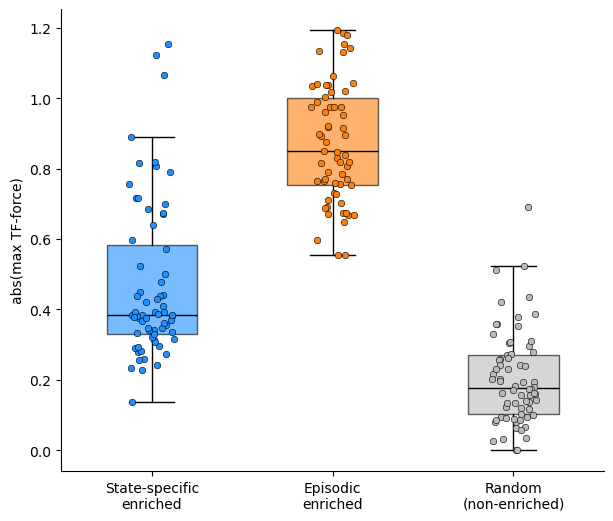

In [16]:
# Combined 3-box comparison: state-specific enriched, episodic enriched, and ONE shared
# random null (size-matched to the larger of the two enriched sets; drawn with every
# TF/target from BOTH sets removed). Each link scored by abs-max TF force across PB & GC
# (network_type defaults to 'w_in', the total-effect network).
combo_df = traj.compare_sets(
    {'State-specific': ss_focal_combined_tuple,
     'Episodic': episodic_links_tuples},
    exclude='tf_and_target', random_state=0,
)
combo_df = drop_zero_force(combo_df)
display(combo_df['group'].value_counts())

fig, ax = TFForceValidation.plot_multi(
    combo_df,
    group_order=['State-specific', 'Episodic', 'random'],
    group_labels=['State-specific\nenriched', 'Episodic\nenriched', 'Random\n(non-enriched)'],
    ylabel='abs(max TF-force)',
    colors=GROUP_COLORS,
)
save_pdf(fig, "combined_links_validation")
plt.show()


## Phase definitions

In [16]:
# Cell-state composition along each segment (the segment's range is filled in);
# termination pseudotimes are the phase boundaries.
sf_pb = traj.state_frequency('PB', config.CELL_LABELS, colors=colors_cell_count)
sf_gc = traj.state_frequency('GC', config.CELL_LABELS, colors=colors_cell_count)
pseudotime_values_of_windows_pb = sf_pb.pseudotime_values_of_windows
pseudotime_values_of_windows_gc = sf_gc.pseudotime_values_of_windows


In [17]:
# PB switch boundaries = termination pseudotimes of ActB-4 then earlyPB (3 phases).
pb_switches = [sf_pb.termination_pseudotime(s, PB_post_bifurcation_window_indices,
                                            method='threshold')
               for s in ['ActB-4', 'earlyPB']]

# GC switch boundary = termination pseudotime of ActB-3 (2 phases).
gc_switches = [sf_gc.termination_pseudotime('ActB-3', GC_post_bifurcation_window_indices,
                                            method='threshold')]

### TF Force Phase split validation

In [19]:
# Classify the universe of enriched links (state-specific + episodic) into PB phases,
# keeping only links whose winning branch is PB, then compare the two enriched sets
# against ONE shared per-phase random null. Each point is a link's abs-max TF force,
# which (since phase = where the force peaks) is its in-phase peak force.
pb_phase_df = traj.compare_sets_by_phase(
    {'State-specific': ss_focal_combined_tuple,
     'Episodic': episodic_links_tuples},
    switch_pseudotimes={'PB': pb_switches},
    exclude='tf_and_target', random_state=0,
)
pb_phase_df = drop_zero_force(pb_phase_df)
display(pb_phase_df.groupby(['phase', 'group']).size().unstack(fill_value=0))


Dropped zero-force links: {'State-specific': [('RUNX2', 'RUNX2')]}


group,Episodic,State-specific,random
phase,,,
1,9,10,11
2,13,26,26
3,8,16,16


In [20]:
# Same for GC phases (links whose winning branch is GC).
gc_phase_df = traj.compare_sets_by_phase(
    {'State-specific': ss_focal_combined_tuple,
     'Episodic': episodic_links_tuples},
    switch_pseudotimes={'GC': gc_switches},
    exclude='tf_and_target', random_state=0,
)
gc_phase_df = drop_zero_force(gc_phase_df)
display(gc_phase_df.groupby(['phase', 'group']).size().unstack(fill_value=0))


group,Episodic,State-specific,random
phase,,,
1,18,12,18
2,14,3,14


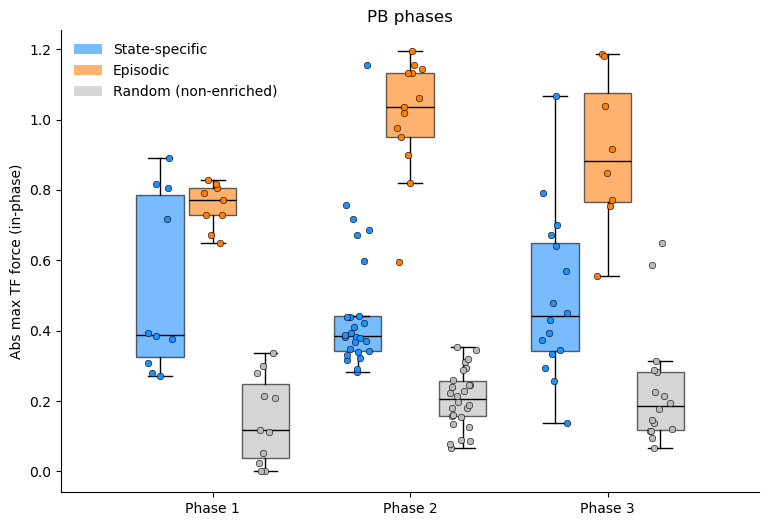

In [21]:
fig, ax = TFForceValidation.plot_multi_by_phase(
    pb_phase_df, branch='PB',
    group_order=['State-specific', 'Episodic', 'random'],
    group_labels=['State-specific', 'Episodic', 'Random (non-enriched)'],
    ylabel='Abs max TF force (in-phase)',
    colors=GROUP_COLORS,
    xlabel= ['Phase 1', 'Phase 2', 'Phase 3']
)
ax.set_title('PB phases')
save_pdf(fig, "pb_phase_links_validation")
plt.show()

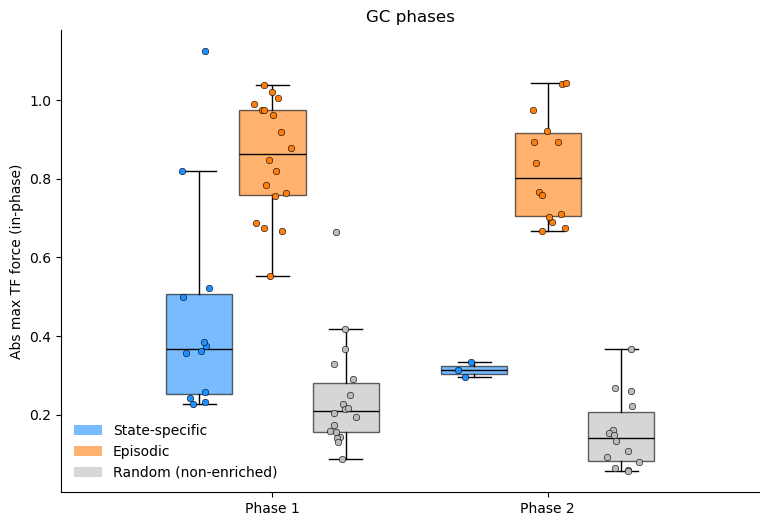

In [22]:
fig, ax = TFForceValidation.plot_multi_by_phase(
    gc_phase_df, branch='GC',
    group_order=['State-specific', 'Episodic', 'random'],
    group_labels=['State-specific', 'Episodic', 'Random (non-enriched)'],
    ylabel='Abs max TF force (in-phase)',
    colors=GROUP_COLORS,
    xlabel=['Phase 1', 'Phase 2'],
)
ax.set_title('GC phases')
save_pdf(fig, "gc_phase_links_validation")
plt.show()

# TF binding dynamics

Moved to `Fig4_4_tf_binding_phases.ipynb`: the per-phase TF binding boxes are built from the
dictys chromatin files and do not use TF forces, so they live in their own notebook.
